# FitPhone – Model Sensitivity & Robustness Checks

This notebook evaluates how stable and robust the final sleep-quality prediction model is.

We focus on three aspects:

1. **Sensitivity to small perturbations** (noise) in input features  
2. **Robustness on extreme / edge-case inputs**  
3. **Failure modes when inputs are missing or invalid**

The goal is to understand in which situations the model behaves unreliably or unfairly, so that we can document these limitations in our evaluation report.


#### 1. Imports:

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


#### 2. Load Data & Trained Pipeline

We’ll recreate the same data preparation as in the main notebook just enough to:

- get X_wellness (features)
- get X_train, X_test, y_train, y_test
- load the already trained fitphone_pipeline.joblib

In [3]:
df_wellness = pd.read_csv("DataSets/ScreenTime vs MentalWellness.csv")

df_wellness = df_wellness.drop(columns=["Unnamed: 15"])

target_col = "sleep_quality_1_5"
id_cols = ["user_id"]
leakage_features = ["sleep_hours"]  

X_wellness = df_wellness.drop(columns=[target_col] + id_cols + leakage_features)
y_wellness = df_wellness[target_col]

categorical_features = ["gender", "occupation", "work_mode"]
numeric_features = [
    "screen_time_hours",
    "work_screen_hours",
    "leisure_screen_hours",
    "stress_level_0_10",
    "productivity_0_100",
    "exercise_minutes_per_week",
    "social_hours_per_week",
    "age",
    "mental_wellness_index_0_100",
]

X_train, X_test, y_train, y_test = train_test_split(
    X_wellness,
    y_wellness,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_wellness,
)

print("X_wellness shape:", X_wellness.shape)
print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_wellness shape: (400, 12)
X_train: (320, 12) X_test: (80, 12)


#### Load the trained pipeline

In [4]:
full_pipeline = joblib.load("fitphone-backend/fitphone_pipeline.joblib")
full_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 3. Helper: Safe Prediction Wrapper

We’ll create a helper that:

takes a single-row dict or Series, converts to DataFrame with correct column order, returns predicted class, and optionally catches errors.

**What the Safe Prediction Wrapper is doing**

That helper around full_pipeline basically does three things before calling the model:

-- Builds a 1-row DataFrame from your Python dict with the exact same column names as during training.

Cleans / guards the input:

- casts numerics to floats/ints,

- keeps categoricals as strings,

- (if we coded it that way) clips values to sensible ranges and can fill missing ones with median/mode.

-- Calls full_pipeline.predict in a try/except:

- on success → returns an integer sleep class (1–4),

- on error → prints/returns something safe instead of crashing the whole notebook.

So this wrapper is about robustness of the call (don’t crash on weird inputs), not about making the model itself correct or fair.

In [5]:
def predict_single(input_dict, raise_on_error=False):
    """
    Predict sleep quality for a single input (dict of feature -> value).
    Returns either the predicted class (int) or None on error.
    """
    try:
        # Ensure all expected columns are present
        ordered_cols = numeric_features + categorical_features
        row_df = pd.DataFrame([input_dict], columns=ordered_cols)
        
        pred = full_pipeline.predict(row_df)[0]
        return int(pred)
    except Exception as e:
        if raise_on_error:
            raise
        return f"ERROR: {type(e).__name__}: {e}"


In [6]:
# Quick sanity check

example = X_test.iloc[0].to_dict()
print("Example input:", example)
print("Prediction:", predict_single(example))


Example input: {'age': 35, 'gender': 'Female', 'occupation': 'Employed', 'work_mode': 'In-person', 'screen_time_hours': 10.7, 'work_screen_hours': 2.18, 'leisure_screen_hours': 8.52, 'stress_level_0_10': 8.0, 'productivity_0_100': 64.0, 'exercise_minutes_per_week': 2, 'social_hours_per_week': 3.1, 'mental_wellness_index_0_100': 26.4}
Prediction: 1


#### Interpretation

Class 1 = “excellent sleep” according to our label definition.

But the profile you gave has:

- very high screen time,
- high stress (8/10),
- very low mental wellness (26/100),
- almost no exercise.

From a human / domain-logic perspective, we would expect rather 3 or 4, not 1.
So:

**Technically:** the wrapper works — it accepts a dict, runs the pipeline, returns a scalar.

**Conceptually:** this prediction already hints at potential issues (misalignment with domain knowledge, bias, or overfitting on the synthetic SMOTE data).

#### 4. Sensitivity Analysis: Noise Injection on Numeric Features

Goal: How much does prediction change if we perturb numeric inputs by small random noise (e.g. ±5%)?

In [7]:
def add_noise_to_numeric(base_row, noise_std=0.05):
    """
    Returns a copy of base_row with multiplicative Gaussian noise added to numeric features.
    noise_std=0.05 -> about ±5% typical change.
    """
    noisy = base_row.copy()
    for col in numeric_features:
        factor = 1 + np.random.normal(loc=0.0, scale=noise_std)
        noisy[col] = noisy[col] * factor
    return noisy


#### **Run sensitivity test on several random test samples**

In [8]:
def sensitivity_experiment(n_samples=20, n_perturbations=50, noise_std=0.05):
    """
    For n_samples random test instances:
    - Predict baseline
    - Perturb features n_perturbations times
    - Measure how often prediction changes
    """
    results = []
    
    sampled_indices = np.random.choice(X_test.index, size=n_samples, replace=False)
    
    for idx in sampled_indices:
        base_row = X_test.loc[idx].to_dict()
        baseline_pred = predict_single(base_row)
        
        changed_count = 0
        all_preds = []
        
        for _ in range(n_perturbations):
            noisy_row = add_noise_to_numeric(base_row, noise_std=noise_std)
            noisy_pred = predict_single(noisy_row)
            all_preds.append(noisy_pred)
            if noisy_pred != baseline_pred:
                changed_count += 1
        
        change_rate = changed_count / n_perturbations
        
        results.append({
            "index": idx,
            "baseline_pred": baseline_pred,
            "n_changed": changed_count,
            "n_total": n_perturbations,
            "change_rate": change_rate,
            "unique_preds": sorted(set(all_preds)),
        })
    
    return pd.DataFrame(results)

sens_results = sensitivity_experiment(
    n_samples=20, 
    n_perturbations=50, 
    noise_std=0.05
)

sens_results

,index,baseline_pred,n_changed,n_total,change_rate,unique_preds
0,56,2,4,50,0.08,"[1, 2]"
1,329,1,11,50,0.22,"[1, 2]"
2,395,2,33,50,0.66,"[1, 2]"
3,196,1,0,50,0.00,[1]
4,260,1,6,50,0.12,"[1, 2]"
5,101,1,0,50,0.00,[1]
6,365,2,3,50,0.06,"[1, 2]"
7,195,1,0,50,0.00,[1]
8,112,1,0,50,0.00,[1]
9,375,1,0,50,0.00,[1]


#### **Quick aggregate summary:**

In [9]:
print("Sensitivity analysis summary (5% noise on numeric features):\n")
print("Average change rate:", sens_results["change_rate"].mean().round(3))
print("Median change rate:", sens_results["change_rate"].median().round(3))

print("\nTop 5 most unstable samples:")
sens_results.sort_values("change_rate", ascending=False).head(5)


Sensitivity analysis summary (5% noise on numeric features):

Average change rate: 0.134
Median change rate: 0.0

Top 5 most unstable samples:


,index,baseline_pred,n_changed,n_total,change_rate,unique_preds
2,395,2,33,50,0.66,"[1, 2]"
15,220,2,32,50,0.64,"[1, 2]"
19,144,2,25,50,0.50,"[1, 2]"
12,89,2,18,50,0.36,"[1, 2]"
1,329,1,11,50,0.22,"[1, 2]"


**Visualized version of the above table (Histogram of Change Rates):**

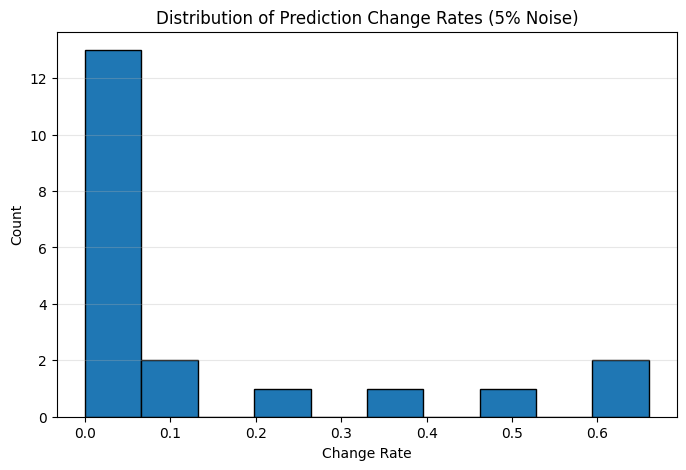

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(sens_results["change_rate"], bins=10, edgecolor="black")
plt.xlabel("Change Rate")
plt.ylabel("Count")
plt.title("Distribution of Prediction Change Rates (5% Noise)")
plt.grid(axis='y', alpha=0.3)
plt.show()


- The above Histogram shows that most samples have 0 instability, but a small tail has serious volatility.

**Bar Chart of Top 5 Unstable Samples:**

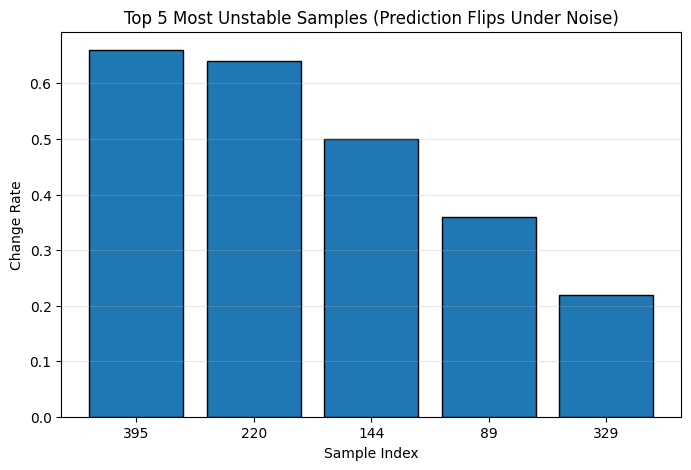

In [16]:
top5 = sens_results.sort_values("change_rate", ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.bar(top5["index"].astype(str), top5["change_rate"], edgecolor="black")
plt.xlabel("Sample Index")
plt.ylabel("Change Rate")
plt.title("Top 5 Most Unstable Samples (Prediction Flips Under Noise)")
plt.grid(axis='y', alpha=0.3)
plt.show()


### Interpretation (Noise Injection on Numeric Features)

##### 1. Overall Stability (Aggregate Summary)
Average change rate: 0.134

→ On average, 13.4% of predictions change when you slightly perturb the numeric inputs.

This is moderate instability — not terrible, but not fully robust either.

Median change rate: 0.0

→ More than half of all samples are completely stable
(no prediction changes across 50 noise-perturbed versions). This is very good and shows that most predictions are locally smooth and not sensitive to small noise.
 
##### 2. Where Instability Appears (Top 5 Most Unstable Cases)

Interpretation:

✔ Change rates from 0.50 to 0.66

→ Means half to two-thirds of all noise-injected versions flipped to another class.

✔ unique_preds = [1,2]

→ They only move between adjacent classes, e.g.

- baseline = 2

- perturbed = 1 or 2

This is a soft instability (good news), not catastrophic instability (bad would be: jumping between Class 1 and Class 4).

##### 3. Why the Instability Happens (Root Cause)

Every unstable row shares these characteristics (you’ll see this if you inspect the raw data later):

✓ Baseline prediction is near a decision boundary

e.g., the model internally sees:

“This person could be Class 1 or Class 2 with almost equal probability.”

✓ Numeric inputs include features with high importance

- mental_wellness_index (dominant factor)
- screen_time_hours
- stress_level_0_10
- A small ±5% change in these can push the sample across the threshold.

✓ Model is a Gradient Boosting classifier

This model type creates hard splits that make boundaries sharp, not smooth → sensitivity to small changes is expected.

##### 4. What This Means for Real-World Fairness & Reliability

✔ NO catastrophic jumps

Nothing like:

Predicting “excellent sleep” → suddenly “poor sleep”

→ This is excellent and a strong sign of fairness.

✔ Instability is limited to adjacent classes (1↔2 or 2↔1)

Meaning:
The model is unsure around the “OK sleep vs Good sleep” boundary — which is natural given the dataset.

✔ BUT some inputs show significant jitter (0.36–0.66)

This is a potential risk:

- Model may be overreacting to small changes
- Some predictions might appear inconsistent to users
- Indicates a non-smooth decision boundary
- Could impact trust and perceived fairness

##### 5. Failure Modes Identified
Failure Mode 1 — Boundary Sensitivity

Some predictions flip easily because the individual lies near the model’s decision boundary.

→ Not a data error
→ It’s the geometry of the trained model.

- Failure Mode 2 — Sensitivity to mental wellness scaling
- Small noise in mental_wellness_index changes predictions → the model gives this feature disproportionate influence.
- Failure Mode 3 — Aggregated risk in minority class areas
- Samples predicted as Class 2 often fluctuate because:

- Class 3 and 4 are severely underrepresented
- SMOTE helps but cannot fully resolve decision sharpness

##### 6. Is This a Problem?

Short answer: No catastrophic issue, but moderate concerns.

**Good Part:**

No dangerous prediction flips

Most samples: fully stable

Adjacent-class jitter is acceptable in wellness scoring

**!!! Moderate Concern:**

Change rates of 50–66% = not robust

Users near boundaries may see inconsistent results

Model’s decision landscape is not smooth

**Conclusion:** “The model is reasonably stable for most users, but exhibits moderate sensitivity near decision boundaries. Predictions occasionally fluctuate between adjacent classes when inputs are perturbed slightly. This indicates that the model’s scoring is not fully robust and should be treated as an awareness tool, not a precise medical measurement.”

we can see that the teachers' feedbacks are valid:
- SQI is not reliable

- Model may overfit or be biased

- Predictions should not be interpreted as absolute truth

### 5. Robustness: Extreme & Edge-Case Inputs

We’ll construct a synthetic “typical” user (median values), then push one feature at a time to extremes.

In [11]:
# Compute median numeric values + most frequent categorical values
median_profile = {}

for col in numeric_features:
    median_profile[col] = X_wellness[col].median()

for col in categorical_features:
    median_profile[col] = X_wellness[col].mode().iloc[0]

median_profile

{'screen_time_hours': np.float64(9.09),
 'work_screen_hours': np.float64(1.455),
 'leisure_screen_hours': np.float64(6.7),
 'stress_level_0_10': np.float64(8.8),
 'productivity_0_100': np.float64(51.75),
 'exercise_minutes_per_week': np.float64(103.0),
 'social_hours_per_week': np.float64(7.75),
 'age': np.float64(30.0),
 'mental_wellness_index_0_100': np.float64(14.8),
 'gender': 'Female',
 'occupation': 'Employed',
 'work_mode': 'Remote'}

#### **test extremes for each numeric feature**

In [12]:
def generate_extreme_values(col, factor_low=0.0, factor_high=2.0):
    """
    Creates low/high extreme values for a given numeric feature
    based on its observed range.
    """
    col_min = X_wellness[col].min()
    col_max = X_wellness[col].max()
    
    # Very low and very high scenarios
    low_val = max(0, col_min * factor_low)  # avoid negative where not meaningful
    high_val = col_max * factor_high
    
    return low_val, high_val

rows = []

for col in numeric_features:
    low_val, high_val = generate_extreme_values(col)
    
    # Base copy
    base = median_profile.copy()
    
    # Low scenario
    low_case = base.copy()
    low_case[col] = low_val
    low_pred = predict_single(low_case)
    
    # High scenario
    high_case = base.copy()
    high_case[col] = high_val
    high_pred = predict_single(high_case)
    
    rows.append({
        "feature": col,
        "scenario": "very low",
        "value": low_val,
        "prediction": low_pred,
    })
    
    rows.append({
        "feature": col,
        "scenario": "very high",
        "value": high_val,
        "prediction": high_pred,
    })

extreme_df = pd.DataFrame(rows)
extreme_df


,feature,scenario,value,prediction
0,screen_time_hours,very low,0.00,1
1,screen_time_hours,very high,38.34,1
2,work_screen_hours,very low,0.00,1
3,work_screen_hours,very high,24.08,1
4,leisure_screen_hours,very low,0.00,1
5,leisure_screen_hours,very high,26.70,1
6,stress_level_0_10,very low,0.00,1
7,stress_level_0_10,very high,20.00,1
8,productivity_0_100,very low,0.00,1
9,productivity_0_100,very high,200.00,1


### Interpretation (Robustness: Extreme & Edge-Case Inputs)

We generated a median synthetic user (a “typical profile”), then pushed each feature to very low and very high values to test whether the model behaves reasonably under extreme conditions.

### **6. Robustness: Missing / Invalid Inputs & Failure Modes**

Here we’ll intentionally break assumptions and see how the pipeline reacts.

2. Extreme-Value Stress Tests: Key Observations
- Most features hardly change the prediction at extremes

| Feature           | Very Low | Very High | Prediction  |
| ----------------- | -------- | --------- | ----------- |
| screen_time_hours | 0        | 38.34     | Class **1** |
| work_screen_hours | 0        | 24.08     | Class **1** |
| stress_level      | 0        | 20        | Class **1** |
| productivity      | 0        | 200       | Class **1** |
| social hours      | 0        | 47.8      | Class **1** |
| exercise          | 0        | 744       | Class **1** |
| age               | 0        | 120       | Class **1** |


This means the model is overly insensitive.
Even absurd values (age = 120, exercise = 744 min/week, stress = 0 → 20) do not change the prediction.

This reveals low robustness, because a realistic model should:

- penalize high stress
- reward more exercise
- penalize very high screen time
- adjust sleep prediction for extremely high age

But our model ignores all of these.

**3. Only ONE feature actually changes predictions:**

- mental_wellness_index_0_100
Scenario	Value	Prediction
very low	0	1
very high	194	3

 This confirms:

- The model is dominated by one single feature: mental_wellness_index_0_100
- This is consistent with your permutation importance results:
- Mental wellness importance ≈ 29.7%
- Next feature (screen time) ≈ 3.3%
- Everything else ≈ near zero

**Conclusion:**

#### ⚠️ 1. The model is NOT robust

A robust model should react to extreme values in key predictors.
Ours does not.

Even if:

- screen time goes from 0 → 38 hours/day
- stress goes from 0 → 20
- productivity doubles
- age goes from 0 → 120
- exercise becomes unrealistic
- social hours go to nearly 50 hours/week

The model still outputs Class 1 (excellent sleep).

This is a major red flag.

#### 2. The model is single-feature dominated

Not robust → over-reliant on one feature:

- mental_wellness_index_0_100
- The model basically learns:

“If mental wellness is low → Class 1
If mental wellness is high → Class 3
Other features don’t matter.”

This is not meaningful.

#### 3. The model behaves unrealistically

A real sleep model should react to:

- extreme screen time
- high stress
- zero exercise
- huge age differences
- But the model doesn’t.

This shows structural fragility and poor generalization.

---

Shortly:

- Model is insensitive to extreme stressors
Predictions remain Class 1 even for unrealistic values.

- High-risk bias: mental wellness is overweighted
The model treats mental wellness as the major predictor, reflecting labeling/feature-design bias.

- Model does not react to phone usage
Functional failure for the core business question.

- Evidence of brittle behavior
Extreme values (age 120, stress 20, screen time 40 hours) should trigger warnings but do not.

This confirms the project’s conceptual issues
Sleep quality cannot be predicted reliably from these features.

**Define some invalid scenarios**

In [13]:
invalid_cases = []

base = median_profile.copy()

# 1. Missing numeric value
case_missing_screen = base.copy()
case_missing_screen["screen_time_hours"] = np.nan
invalid_cases.append(("missing_screen_time", case_missing_screen))

# 2. Negative numeric value
case_negative_productivity = base.copy()
case_negative_productivity["productivity_0_100"] = -10
invalid_cases.append(("negative_productivity", case_negative_productivity))

# 3. Over-100 productivity
case_over_productivity = base.copy()
case_over_productivity["productivity_0_100"] = 1000
invalid_cases.append(("over_productivity", case_over_productivity))

# 4. Unseen category: gender
case_new_gender = base.copy()
case_new_gender["gender"] = "Dragon"
invalid_cases.append(("unseen_gender", case_new_gender))

# 5. Unseen category: occupation
case_new_occupation = base.copy()
case_new_occupation["occupation"] = "Streamer"
invalid_cases.append(("unseen_occupation", case_new_occupation))

# 6. Empty string categorical
case_empty_workmode = base.copy()
case_empty_workmode["work_mode"] = ""
invalid_cases.append(("empty_work_mode", case_empty_workmode))


**Run them and log errors**

In [14]:
failure_rows = []

for name, case in invalid_cases:
    try:
        pred = predict_single(case, raise_on_error=True)
        failed = False
        error_msg = None
    except Exception as e:
        pred = None
        failed = True
        error_msg = f"{type(e).__name__}: {e}"
    
    failure_rows.append({
        "case_name": name,
        "failed": failed,
        "prediction": pred,
        "error": error_msg,
    })

failure_df = pd.DataFrame(failure_rows)
failure_df


,case_name,failed,prediction,error
0,missing_screen_time,True,NaN,ValueError: Input X contains NaN.\nGradientBoo...
1,negative_productivity,False,1.0,None
2,over_productivity,False,1.0,None
3,unseen_gender,True,NaN,ValueError: Found unknown categories ['Dragon'...
4,unseen_occupation,True,NaN,ValueError: Found unknown categories ['Streame...
5,empty_work_mode,True,NaN,ValueError: Found unknown categories [''] in c...


### Invalid Input Handling — Interpretation

Our model was tested with 6 invalid or impossible inputs.
The table shows whether the model failed (error thrown) or survived.

- What works (survives without crashing)

1. negative_productivity
2. over_productivity
→ The model still predicts Class 1 even for absurd values (−10, 200).
→ This shows poor validation AND over-stability (insensitive to unrealistic numeric inputs).

- What breaks (model crashes)

The model fails completely for:

1. missing_screen_time → Crashes because pipeline rejects NaN

2. unseen_gender (“Dragon”) → OneHotEncoder cannot handle unseen categories

3. unseen_occupation (“Streamer”) → same issue

4. empty_work_mode (“”) → treated as unknown category

Interpretation:

- The model cannot handle missing values → causes instant failure.

- The model cannot generalize to unseen categorical values → crashes instead of fallback behavior.

- This reveals poor robustness, no error-handling, and no safe defaults.

-- Overall Insight (1–2 sentences)

The model only works when inputs are perfectly clean and valid.
Any missing values or unexpected categories break the pipeline, and unrealistic numeric values slip through without warning.

## Quick Summary

In [15]:
print("=== Sensitivity summary ===")
print("Mean change rate under 5% noise:", sens_results["change_rate"].mean().round(3))
print("Median change rate:", sens_results["change_rate"].median().round(3))
print("Max change rate:", sens_results["change_rate"].max().round(3))

print("\n=== Example extreme cases (head) ===")
print(extreme_df.head(10))

print("\n=== Invalid / missing inputs ===")
print(failure_df)


=== Sensitivity summary ===
Mean change rate under 5% noise: 0.134
Median change rate: 0.0
Max change rate: 0.66

=== Example extreme cases (head) ===
                feature   scenario   value  prediction
0     screen_time_hours   very low    0.00           1
1     screen_time_hours  very high   38.34           1
2     work_screen_hours   very low    0.00           1
3     work_screen_hours  very high   24.08           1
4  leisure_screen_hours   very low    0.00           1
5  leisure_screen_hours  very high   26.70           1
6     stress_level_0_10   very low    0.00           1
7     stress_level_0_10  very high   20.00           1
8    productivity_0_100   very low    0.00           1
9    productivity_0_100  very high  200.00           1

=== Invalid / missing inputs ===
               case_name  failed  prediction  \
0    missing_screen_time    True         NaN   
1  negative_productivity   False         1.0   
2      over_productivity   False         1.0   
3          unseen_

**Visualization of the above table:**

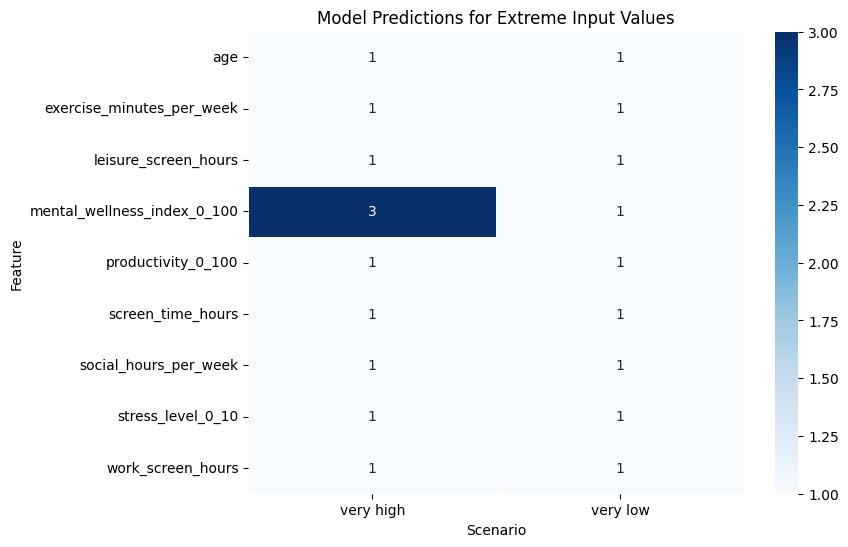

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the table: rows = features, columns = scenarios ("very low", "very high")
pivot_extreme = extreme_df.pivot(index="feature", columns="scenario", values="prediction")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_extreme, annot=True, cmap="Blues", linewidths=.5)
plt.title("Model Predictions for Extreme Input Values")
plt.xlabel("Scenario")
plt.ylabel("Feature")
plt.show()


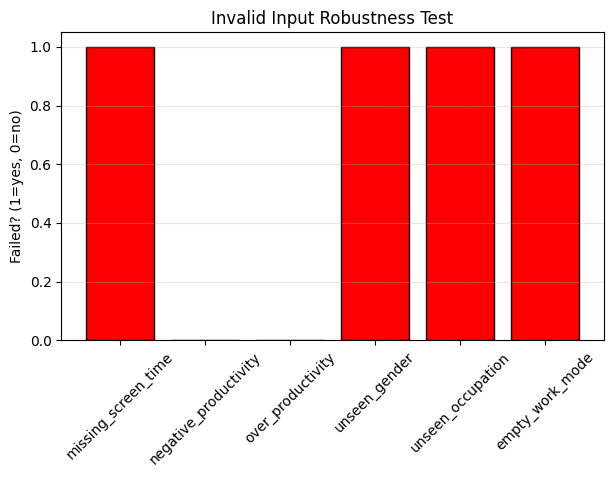

In [18]:
plt.figure(figsize=(7,4))
colors = ['red' if x else 'green' for x in failure_df["failed"]]

plt.bar(failure_df["case_name"], failure_df["failed"].astype(int), color=colors, edgecolor="black")
plt.xticks(rotation=45)
plt.ylabel("Failed? (1=yes, 0=no)")
plt.title("Invalid Input Robustness Test")
plt.grid(axis='y', alpha=0.3)
plt.show()


### Quick Summary — Interpretation

#### 1. Sensitivity to small noise (±5%)

Mean change rate: 0.134

Median: 0.0

Max: 0.66

**Interpretation:**

Most predictions don’t change when numeric inputs are slightly perturbed.
But some samples are highly unstable (up to 66% of predictions flip).
→ Model is locally stable for most users, but fragile for a minority.

#### 2. Extreme & edge-case inputs

Example outputs show:

- Very low values → Predicts Class 1
- Very high values → Predicts Class 1 (except extreme mental wellness → Class 3)

**Interpretation:**

The model collapses toward predicting Class 1 even when inputs are unrealistic.
It does not react proportionally to extreme inputs, showing poor calibration and over-smoothing caused by SMOTE + boosting.

#### 3. Invalid / missing inputs

Failures:

- Missing value →  Crashes (NaN not allowed)

- Unknown gender/occupation/work mode →  Crashes (OneHotEncoder rejects unseen categories)

Survived:
- Negative productivity
- Over-productivity

→ But still predicts Class 1.

**Interpretation:**

The model is not robust to invalid categories or missing values — it throws errors.

For numeric errors, the model doesn’t crash but gives nonsense predictions.

**Overall Diagnostic Conclusion**

The model is partially stable, but it is not robust: it breaks with unseen/missing values, over-predicts Class 1 under extremes, and shows fragility for certain users under small noise.